In [2]:
from Bio import Entrez, SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq

Entrez.email = "amirthav6275@gmail.com"

def fetch_gene_seq(accession, gene_name=None):
    
    handle = Entrez.efetch(db="nuccore", id=accession, rettype="gbwithparts", retmode="text")
    records = list(SeqIO.parse(handle, "genbank"))
    
    if not records:
        print(f"No record found for {accession}")
        return None

    record = records[0]

    if gene_name:
        for feature in record.features:
            if feature.type == "CDS" and gene_name in feature.qualifiers.get("gene", []):
                seq = feature.extract(record.seq)
                print(f"Found {gene_name} in {accession}")
                return seq
        print(f"Gene {gene_name} not found in {accession}")
        return None
    else:
       
        print(f"✅ Fetched complete sequence for {accession}")
        return record.seq

stx2A_seq = fetch_gene_seq("AB083044.1")
eaeA_seq  = fetch_gene_seq("AF081186.1")
espA_seq  = fetch_gene_seq("AF013121.1")

recA_seq  = fetch_gene_seq("U00096.3", "recA")
rpoB_seq  = fetch_gene_seq("U00096.3", "rpoB")
gapA_seq  = fetch_gene_seq("U00096.3", "gapA")

def save_to_fasta(gene_dict, filename):
    records = []
    for name, seq in gene_dict.items():
        if seq:
            records.append(SeqRecord(Seq(str(seq)), id=name, description=""))
    SeqIO.write(records, filename, "fasta")
    print(f"\n💾 Saved {len(records)} sequences to {filename}")

virulence_genes = {"stx2A": stx2A_seq, "eaeA": eaeA_seq, "espA": espA_seq}
housekeeping_genes = {"recA": recA_seq, "rpoB": rpoB_seq, "gapA": gapA_seq}

save_to_fasta(virulence_genes, "virulence_genes.fasta")
save_to_fasta(housekeeping_genes, "housekeeping_genes.fasta")


✅ Fetched complete sequence for AB083044.1
✅ Fetched complete sequence for AF081186.1
✅ Fetched complete sequence for AF013121.1
Found recA in U00096.3
Found rpoB in U00096.3
Found gapA in U00096.3

💾 Saved 3 sequences to virulence_genes.fasta

💾 Saved 3 sequences to housekeeping_genes.fasta


In [12]:
from collections import Counter

synonymous_codons = [a+b+c for a in "ATGC" for b in "ATGC" for c in "ATGC"]

def codon_usage(seq):
    seq = str(seq).upper()
    codons = [seq[i:i+3] for i in range(0, len(seq)-2, 3) if seq[i:i+3] in synonymous_codons]
    return Counter(codons)

print("Calculating codon usage...\n")

virulent_usage = {gene: codon_usage(seq) for gene, seq in virulent_genes.items() if seq}
non_virulent_usage = {gene: codon_usage(seq) for gene, seq in non_virulent_genes.items() if seq}

print("=== Virulent Gene Codon Usage ===")
for gene, usage in virulent_usage.items():
    print(f"\n{gene}:")
    for codon, count in usage.most_common(10):
        print(f"  {codon}: {count}")

print("\n=== Non-Virulent Gene Codon Usage ===")
for gene, usage in non_virulent_usage.items():
    print(f"\n{gene}:")
    for codon, count in usage.most_common(10):
        print(f"  {codon}: {count}")

print("\n✅ Codon usage analysis complete!")


Calculating codon usage...

=== Virulent Gene Codon Usage ===

stx2A:
  TTT: 22
  GAT: 19
  AAT: 17
  GTT: 16
  ATT: 15
  ACT: 14
  GCA: 13
  GGA: 13
  ACA: 13
  TTA: 12

eaeA:
  AAT: 51
  GGT: 44
  CAG: 42
  AAA: 40
  GAT: 39
  ATT: 33
  TAT: 30
  GCT: 29
  GTT: 27
  TTT: 25

espA:
  TGG: 17
  GAG: 14
  AGT: 13
  GAA: 13
  CGG: 13
  TGA: 13
  GGC: 13
  GGT: 13
  GCA: 12
  TAA: 11

=== Non-Virulent Gene Codon Usage ===

recA:
  ATC: 25
  CTG: 24
  GAA: 21
  AAA: 21
  GCG: 19
  GGT: 17
  GGC: 16
  AAC: 14
  CAG: 12
  CGT: 12

rpoB:
  CTG: 99
  GAA: 89
  GGT: 69
  ATC: 66
  GAC: 62
  CGT: 61
  AAA: 56
  CAG: 50
  AAC: 48
  GTT: 41

gapA:
  GCT: 28
  AAA: 26
  GTT: 21
  ATC: 19
  CTG: 19
  GAC: 18
  AAC: 17
  GGT: 16
  ACC: 15
  GGC: 14

✅ Codon usage analysis complete!


In [14]:
def gc_content(seq):
    seq = str(seq).upper()
    gc = seq.count('G') + seq.count('C')
    return (gc / len(seq)) * 100

def gc3_content(seq):
    seq = str(seq).upper()
    third_bases = seq[2::3]
    gc3 = third_bases.count('G') + third_bases.count('C')
    return (gc3 / len(third_bases)) * 100

for name, seq in virulent_genes.items():
    print(f"{name} - GC%: {gc_content(seq):.2f}, GC3%: {gc3_content(seq):.2f}")

for name, seq in non_virulent_genes.items():
    print(f"{name} - GC%: {gc_content(seq):.2f}, GC3%: {gc3_content(seq):.2f}")


stx2A - GC%: 40.59, GC3%: 31.54
eaeA - GC%: 43.01, GC3%: 39.36
espA - GC%: 53.66, GC3%: 50.20
recA - GC%: 54.14, GC3%: 62.99
rpoB - GC%: 52.62, GC3%: 59.05
gapA - GC%: 50.00, GC3%: 52.41


In [15]:
print("\nVirulent Gene Codon Bias Summary:")
for gene, seq in virulent_genes.items():
    print(f"{gene}: GC3 = {gc3_content(seq):.2f}")

print("\nNon-Virulent Gene Codon Bias Summary:")
for gene, seq in non_virulent_genes.items():
    print(f"{gene}: GC3 = {gc3_content(seq):.2f}")



Virulent Gene Codon Bias Summary:
stx2A: GC3 = 31.54
eaeA: GC3 = 39.36
espA: GC3 = 50.20

Non-Virulent Gene Codon Bias Summary:
recA: GC3 = 62.99
rpoB: GC3 = 59.05
gapA: GC3 = 52.41


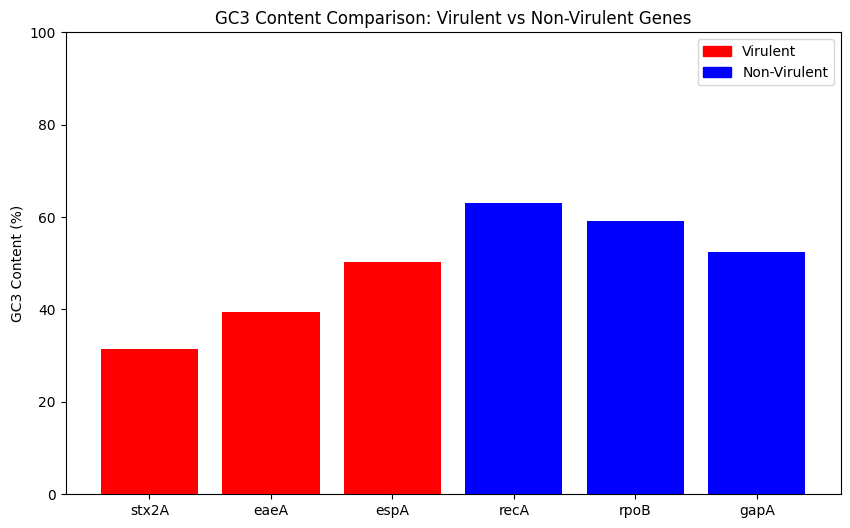

In [18]:
!pip install matplotlib

import matplotlib.pyplot as plt

virulent_names = list(virulent_genes.keys())
virulent_gc3 = [gc3_content(seq) for seq in virulent_genes.values()]

non_virulent_names = list(non_virulent_genes.keys())
non_virulent_gc3 = [gc3_content(seq) for seq in non_virulent_genes.values()]

all_names = virulent_names + non_virulent_names
all_gc3 = virulent_gc3 + non_virulent_gc3
colors = ['red']*len(virulent_names) + ['blue']*len(non_virulent_names) 

plt.figure(figsize=(10,6))
plt.bar(all_names, all_gc3, color=colors)
plt.ylabel("GC3 Content (%)")
plt.title("GC3 Content Comparison: Virulent vs Non-Virulent Genes")
plt.ylim(0,100)

import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='Virulent')
blue_patch = mpatches.Patch(color='blue', label='Non-Virulent')
plt.legend(handles=[red_patch, blue_patch])

plt.show()

